### import libraries

In [2]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import config, db
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
sns.set_style("whitegrid")
%matplotlib inline

### load data 

In [3]:
client = db.get_client()
collection = db.get_collection(config.FEATURES_COLLECTION, client)
cursor = collection.find({"city": config.CITY_NAME}).sort("timestamp", 1)
df = pd.DataFrame(list(cursor))
client.close()
df = df.drop(columns=["nh3", "_id"])
df = df.sort_values("timestamp").reset_index(drop=True)
print(df.shape)

(17544, 21)


### (target + split, ONE TIME)

In [4]:
HORIZON_HOURS = 72
df["aqi_target"] = df["aqi"].shift(-HORIZON_HOURS)
df = df.dropna(subset=["aqi_target"]).reset_index(drop=True)

split_index = int(len(df) * 0.85)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
print(train_df.shape, test_df.shape)

(14851, 22) (2621, 22)


### (features, original best set — no rolling features):

In [5]:
feature_cols = [
    "aqi", "pm2_5", "pm10", "co", "no2", "so2", "o3",
    "temperature", "humidity", "pressure", "wind_speed",
    "hour", "day", "month", "day_of_week", "aqi_change_rate",
]
X_train = train_df[feature_cols]
y_train = train_df["aqi_target"]
X_test = test_df[feature_cols]
y_test = test_df["aqi_target"]
print(X_train.shape, X_test.shape)

(14851, 16) (2621, 16)


### (train and compare, clean run):

In [6]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Ridge Regression": Ridge(alpha=1.0),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.3f}")

pd.DataFrame(results)

Random Forest: RMSE=15.11, MAE=11.30, R2=0.013
Ridge Regression: RMSE=16.07, MAE=11.83, R2=-0.117
Gradient Boosting: RMSE=14.09, MAE=10.22, R2=0.141


,model,RMSE,MAE,R2
0,Random Forest,15.109419,11.297010,0.012895
1,Ridge Regression,16.071954,11.828875,-0.116877
2,Gradient Boosting,14.091282,10.219303,0.141444


### reconfirm naive baseline in this clean run

In [7]:
naive_preds = X_test["aqi"]
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_r2 = r2_score(y_test, naive_preds)
print(f"Naive baseline: RMSE={naive_rmse:.2f}, MAE={naive_mae:.2f}, R2={naive_r2:.3f}")

Naive baseline: RMSE=18.58, MAE=13.71, R2=-0.493


### feature importance

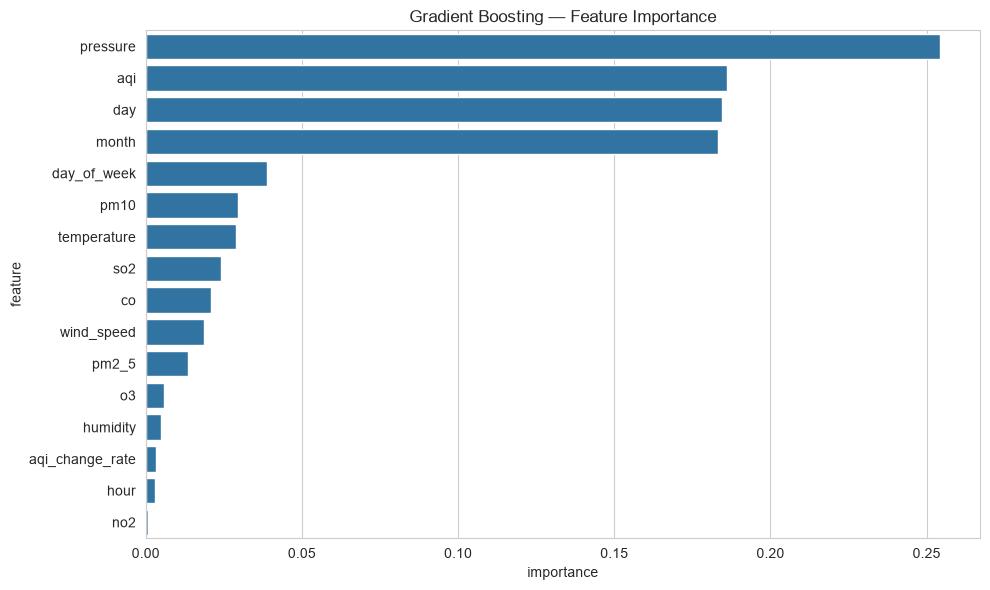

,feature,importance
9,pressure,0.254373
0,aqi,0.186068
12,day,0.184504
13,month,0.183103
14,day_of_week,0.038944
2,pm10,0.029689
7,temperature,0.028807
5,so2,0.024165
3,co,0.021031
10,wind_speed,0.018583


In [8]:
gb_model = models["Gradient Boosting"]
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": gb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Gradient Boosting — Feature Importance")
plt.tight_layout()
plt.show()

importance_df